In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load the house price dataset
df = pd.read_csv('House Price Prediction Dataset.csv')

# Display dimensions and first few records
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.25.2
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Dataset Shape: (2000, 10)

First 5 rows:


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load the house price dataset
df = pd.read_csv('House Price Prediction Dataset.csv')
S
# Display dimensions and first few records
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (2000, 10)

First 5 rows:


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [3]:
# Check data types and non-null counts
print("--- Data Summary & Missing Values ---")
print(df.info())

print("\n--- Missing Values Count Per Column ---")
print(df.isnull().sum())

--- Data Summary & Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB
None

--- Missing Values Count Per Column ---
Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64


In [4]:
# 1. Drop unnecessary 'Id' column
df_processed = df.drop(columns=['Id'])

# 2. Convert categorical text columns to numeric dummy variables (One-Hot Encoding)
df_processed = pd.get_dummies(df_processed, drop_first=True)

# 3. Define Features (X) and Target (y)
X = df_processed.drop(columns=['Price'])
y = df_processed['Price']

print("--- Data Shapes After Encoding ---")
print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

print("\n--- Encoded Feature Columns ---")
print(X.columns.tolist())

--- Data Shapes After Encoding ---
Features (X) shape: (2000, 12)
Target (y) shape: (2000,)

--- Encoded Feature Columns ---
['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Location_Rural', 'Location_Suburban', 'Location_Urban', 'Condition_Fair', 'Condition_Good', 'Condition_Poor', 'Garage_Yes']


In [5]:
# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42
)

print("--- Train-Test Split Verification ---")
print("Total Samples :", len(X))
print("Training Samples (80%):", len(X_train))
print("Testing Samples  (20%):", len(X_test))

--- Train-Test Split Verification ---
Total Samples : 2000
Training Samples (80%): 1600
Testing Samples  (20%): 400


--- Linear Regression Evaluation ---
Mean Squared Error (MSE) : 78321466146.0328
Mean Absolute Error (MAE): 243241.9776
R² Score                 : -0.0067


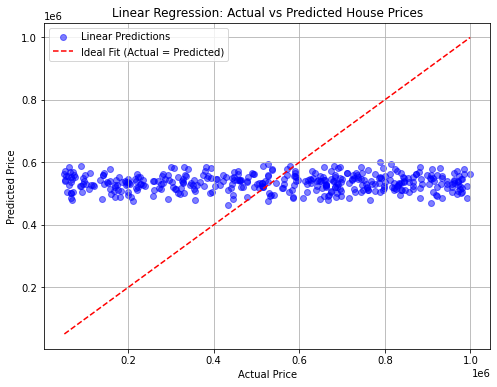

In [6]:
# 1. Initialize and train Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# 2. Predict on test set
y_pred_linear = linear_model.predict(X_test)

# 3. Calculate metrics
mse_linear = mean_squared_error(y_test, y_pred_linear)
mae_linear = mean_absolute_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("--- Linear Regression Evaluation ---")
print("Mean Squared Error (MSE) :", round(mse_linear, 4))
print("Mean Absolute Error (MAE):", round(mae_linear, 4))
print("R² Score                 :", round(r2_linear, 4))

# 4. Plot Actual vs Predicted Prices
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_linear, alpha=0.5, color='blue', label='Linear Predictions')

# Ideal prediction line (Actual = Predicted)
min_val = min(y_test.min(), y_pred_linear.min())
max_val = max(y_test.max(), y_pred_linear.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal Fit (Actual = Predicted)')

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Linear Regression: Actual vs Predicted House Prices')
plt.legend()
plt.grid(True)
plt.show()

--- Polynomial Regression (Degree 2) Evaluation ---
Mean Squared Error (MSE) : 83102828055.7584
Mean Absolute Error (MAE): 249962.6482
R² Score                 : -0.0682


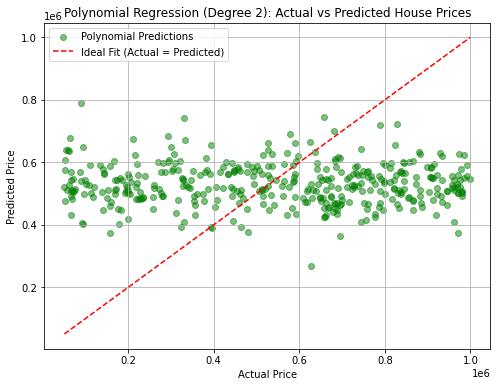

In [7]:
# 1. Build Polynomial Regression Pipeline (Degree 2)
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("linear", LinearRegression())
])

# 2. Fit model on training data
poly_model.fit(X_train, y_train)

# 3. Predict on test set
y_pred_poly = poly_model.predict(X_test)

# 4. Calculate metrics
mse_poly = mean_squared_error(y_test, y_pred_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("--- Polynomial Regression (Degree 2) Evaluation ---")
print("Mean Squared Error (MSE) :", round(mse_poly, 4))
print("Mean Absolute Error (MAE):", round(mae_poly, 4))
print("R² Score                 :", round(r2_poly, 4))

# 5. Plot Actual vs Predicted Prices
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_poly, alpha=0.5, color='green', label='Polynomial Predictions')

# Ideal prediction line
min_val = min(y_test.min(), y_pred_poly.min())
max_val = max(y_test.max(), y_pred_poly.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal Fit (Actual = Predicted)')

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Polynomial Regression (Degree 2): Actual vs Predicted House Prices')
plt.legend()
plt.grid(True)
plt.show()

--- Model Performance Comparison ---


,Model,MSE,MAE,R² Score
0,Linear Regression,7.832147e+10,243241.9776,-0.0067
1,Polynomial Regression (Degree 2),8.310283e+10,249962.6482,-0.0682


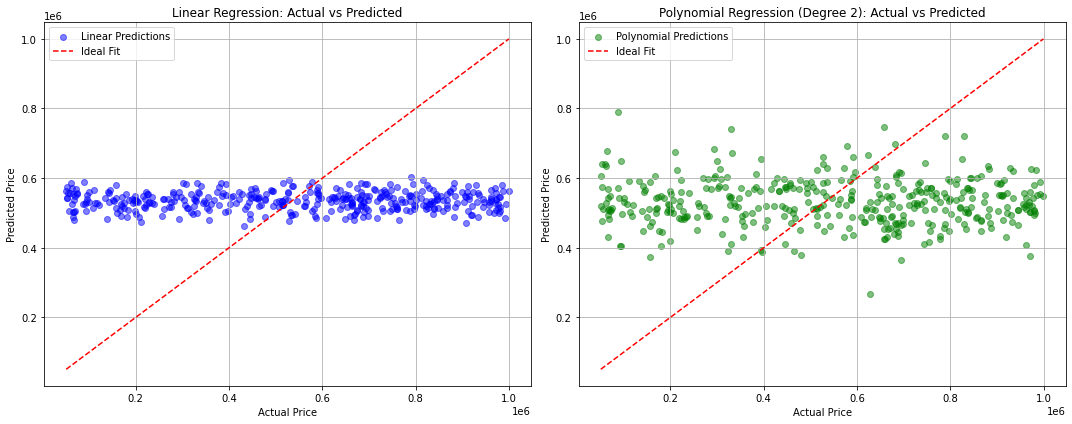

In [8]:
# 1. Create Model Comparison Table
comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Polynomial Regression (Degree 2)"],
    "MSE": [mse_linear, mse_poly],
    "MAE": [mae_linear, mae_poly],
    "R² Score": [r2_linear, r2_poly]
})

print("--- Model Performance Comparison ---")
display(comparison_df.round(4))

# 2. Side-by-Side Plot Comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot Linear Regression
axes[0].scatter(y_test, y_pred_linear, alpha=0.5, color='blue', label='Linear Predictions')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal Fit')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title('Linear Regression: Actual vs Predicted')
axes[0].legend()
axes[0].grid(True)

# Plot Polynomial Regression
axes[1].scatter(y_test, y_pred_poly, alpha=0.5, color='green', label='Polynomial Predictions')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal Fit')
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')
axes[1].set_title('Polynomial Regression (Degree 2): Actual vs Predicted')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()